In [24]:
from functions.internal import load_dataset_1A, normalization, extract_timeseries, visualize_graph_internal
from functions.SQUIC_functions import squic_fit_matrix_computation, squic_fit_computation, check_symmetric_sparse
from functions.clustering_functions import clustering_2_communities, ARI_fscore, plot_ARI_f1, study_CC
import matplotlib.pyplot as plt
import json
from scipy import sparse
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
import os
import networkx as nx

In [25]:
def ask_yes_no(prompt, default=None):
    """
    Ask the user a yes/no question with optional default.
    """
    while True:
        answer = input(f"{prompt} (Y/N) ").strip().upper()
        if not answer and default:
            return default
        if answer in ['Y', 'N']:
            return answer
        print("Please enter 'Y' or 'N'.")


def ask_input(prompt, default=None):
    """
    Ask the user for input with optional default.
    """
    answer = input(f"{prompt} ").strip()
    if not answer and default is not None:
        return default
    return answer

Head of Y_norm df:
          0         1         2         3         4         5         6  \
0  0.000000  0.003719  0.004257  0.004288  0.004288  0.004288  0.005369   
1  0.241697  0.241697  0.241697  0.241697  0.241697  0.241697  0.241697   
2  0.037767  0.037767  0.037767  0.037767  0.037767  0.037767  0.037767   
3  0.000002  0.000002  0.000002  0.000002  0.000002  0.000002  0.000002   
4  0.000024  0.259611  0.259611  0.259611  0.259611  0.259611  0.779544   

          7         8         9  ...       355       356       357       358  \
0  0.012311  0.040661  0.088421  ...  3.541597  3.583763  3.604785  3.619848   
1  0.490280  2.624175  3.485059  ...  6.209161  5.896362  5.669104  5.800662   
2  0.075621  0.169063  0.164084  ...  2.918261  2.918261  2.910340  2.910340   
3  0.000002  0.087905  0.256841  ...  1.370341  1.370341  1.301358  1.292891   
4  0.779544  0.779544  1.013401  ...  4.046056  5.196552  4.056376  4.898807   

        359       360       361       362       3

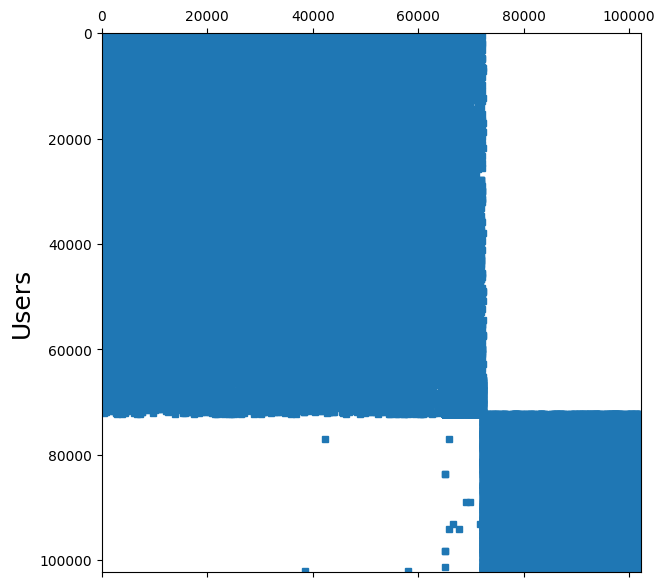


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    4.338292e+00
 Y:         102249 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999200e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=3.88e+00 time=1.08e+01
* iter=1 time=1.19e+00 obj=1.95e+05 |delta(obj)|/obj=4.81e-01 nnz(X,L,W)/p=[3.88e+00 9.65e+01 1.00e+00] lns_iter=5 
* iter=2 time=1.61e+01 obj=1.89e+05 |delta(obj)|/obj=3.34e-02 nnz(X,L,W)/p=[3.88e+00 9.65e+01 3.94e+00] lns_iter=5 
* iter=3 time=5.61e+01 obj=1.75e+05 

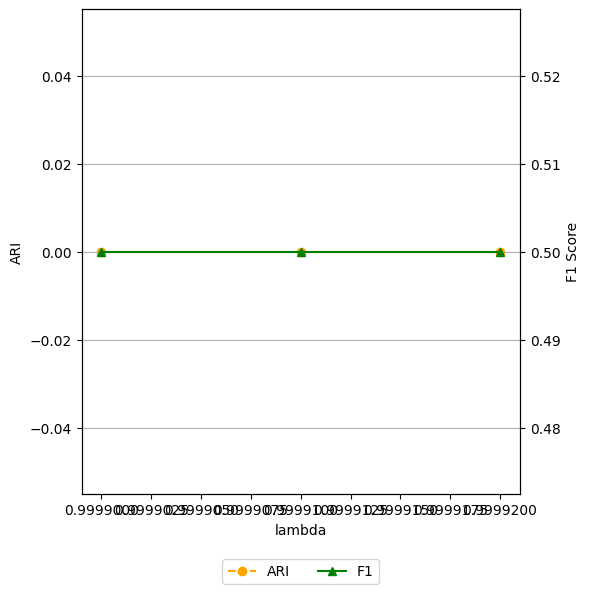

In [26]:
user_input = ask_yes_no("\nDo you want to load data?")

if user_input == 'Y':
    dimension = ask_input("Which dimension (100/1K/10K/100K/1M)?").upper()
    path = 'paysim_data_saved'

    try:
        # Load pre-saved Y_norm
        chunk_size = 10000
        chunks = []

        for chunk in pd.read_csv(f'{path}/YNorm_{dimension}.csv', chunksize=chunk_size):
            chunks.append(chunk)

        Y_norm = pd.concat(chunks, ignore_index=True)
        print(f"Head of Y_norm df:")
        print(Y_norm.head())

        print(f"\ndimension of YNorm loaded: {Y_norm.shape}")

        std_dev = round(np.mean(np.std(Y_norm, axis=1)), 2)

        if not(std_dev > 0.9 and std_dev <= 1):
            print("Mean std per row (should be 1):", std_dev)
            print("Max:", np.max(Y_norm))
            print("Min:", np.min(Y_norm))

            # Step 1: Convert DataFrame to NumPy array for performance
            Y = Y_norm.to_numpy()  # shape: (num_users, num_days)

            # Step 2: Compute row-wise standard deviation
            stds = np.std(Y, axis=1)
            safe_stds = np.clip(stds, 1e-8, None)  # Avoid division by near-zero

            # Step 3: Normalize each row by its std using broadcasting
            Y = Y / safe_stds[:, np.newaxis]

            Y_norm = pd.DataFrame(Y, index=Y_norm.index, columns=Y_norm.columns)

            print(f"Head of Y_norm df:")
            print(Y_norm.head())

            print("Mean std after normalization (should be ~1):", np.mean(np.std(Y_norm, axis=1)))
            print("Max:", np.max(Y_norm))
            print("Min:", np.min(Y_norm))
        else:
            print("Mean std per row (should be 1):", std_dev)

        # Load pre-saved knn_matrix
        knn_matrix = sparse.load_npz(f'{path}/knn_matrix_{dimension}.npz')

        print("Shape KNN:", knn_matrix.shape)
        print("nnz KNN:", knn_matrix.nnz)

        # Average number of non-zeros per row
        nnz_per_row = knn_matrix.nnz / knn_matrix.shape[0]
        print("nnz per row:", round(nnz_per_row, 2))

        print("Is symmetric:", check_symmetric_sparse(knn_matrix))
        
        # Load pre-saved account_properties
        with open(f'{path}/account_prop_{dimension}.json', 'r') as f:
            account_prop = json.load(f)

        account_prop = {int(k): v for k, v in account_prop.items()}
        
        name = 'PAYSIM'

    except Exception as e:
        # If data are not present
        print(f"Error loading data: {e}")
        exit(1)
    
else: # Normal run
    Y, name, dimension, account_prop = load_dataset_1A()

    # visualize timeseries
    extract_timeseries(Y, name, dimension)

    print(Y)

    # now this is good
    print(Y.shape)
    dim1, dim2 = Y.shape
    if dim1 == 365:
        Y = Y.T

    # norm is ok -> lead to SQUIC-Fit results that we want
    Y_norm = normalization(Y, name)

    # visualize timeseries with normalized data
    extract_timeseries(Y_norm, name, dimension, type_df='norm')

    print(Y_norm)

    print("NaNs in df?", np.isnan(Y_norm.values).any())
    print("Infs in df?", np.isinf(Y_norm.values).any())
    print("Max:", np.max(Y_norm))
    print("Min:", np.min(Y_norm))
    print("Mean std per row (should be 1):", round(np.mean(np.std(Y_norm, axis=1)), 2))

    n_neigs = {
        '100' : 10,
        '1K' : 8,
        '10K' : 4,
        '100K' : 3,
        '1M' : 2 # then remove self loops
    }

    nbrs = NearestNeighbors(n_neighbors=n_neigs[dimension], metric='euclidean', n_jobs=-1)
    nbrs.fit(Y_norm)
    knn_matrix = nbrs.kneighbors_graph(Y_norm, mode='connectivity')

    if dimension == '1M':
        # Remove self-loops
        knn_matrix.setdiag(0)
        knn_matrix.eliminate_zeros()
    
    # Ask user if want to save the data for next runs
    if ask_yes_no("Do you want to cache this data?") == 'Y':
        path = 'paysim_data_saved'

        # if path does not exists, create it
        os.makedirs(path, exist_ok=True)
        
        # Save Y_norm as CSV
        pd.DataFrame(Y_norm).to_csv(f'{path}/YNorm_{dimension}.csv', index=False)
        
        # Save account_prop as json
        with open(f'{path}/account_prop_{dimension}.json', 'w') as f:
            json.dump(account_prop, f)
        
        # Save knn_matrix as npz
        sparse.save_npz(f'{path}/knn_matrix_{dimension}.npz', knn_matrix)

results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':

    os.makedirs(f'images/{dimension}/', exist_ok=True)

    # Print knn matrix
    plt.figure(figsize=(7, 7))
    plt.spy(knn_matrix, markersize=5)
    plt.ylabel("Users", fontsize=18)
    plt.savefig(f'images/{dimension}/knn_matrix')
    plt.show()

    if ask_yes_no("Do you want to study the CC of KNN matrix?") == 'Y':
        study_CC(knn_matrix)

    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False
    
    squic_method = 'squic-fit-matrix'
    results_squic[squic_method] = squic_fit_matrix_computation(Y_norm, name, dimension, knn_matrix, printMatrix, save)

else:
    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False

    squic_method = 'squic-fit'
    results_squic[squic_method] = squic_fit_computation(Y_norm, name, dimension, printMatrix, save)

# Results
dict_cluster = clustering_2_communities(results_squic, squic_method)

metrics = ARI_fscore(dict_cluster, results_squic, account_prop)

for _, data in metrics.items():
    for rho, results in data.items():
        print(f"for rho = {rho} : {results}")

plot_ARI_f1(metrics, squic_method, dimension, save)

In [27]:
# for rho, clustering in dict_cluster[squic_method].items():
#     print(rho, clustering)

In [28]:
# results_squic[squic_method]

In [29]:
widget_dict = visualize_graph_internal(results_squic, squic_method, dict_cluster, account_prop, name, two_comm=False)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/anaconda3/envs/bank/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_4390/1200097.py", line 1, in <module>
    widget_dict = visualize_graph_internal(results_squic, squic_method, dict_cluster, account_prop, name, two_comm=False)
  File "/Users/claudio/Documents/USI/Tesi/FinancialCrimeModels/functions/internal.py", line 345, in visualize_graph_internal
TypeError: 'NoneType' object is not iterable

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/envs/bank/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 2144, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "/opt/anaconda3/envs/bank/lib/python3.10/site-packages/IPython/core/ultratb.py", line 1435, in structured_

In [22]:
rho = 0.995

In [23]:
widget_dict[rho]["spectral"]

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…